In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd

import datetime as dt

In [2]:
df = pd.read_csv("./auxiliary/instrument_availability.csv", delimiter="\t")
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True)

print(df)

          DATE  DIY_ASI  COMM_ASI  CEILOMETER
0   2026-01-23        1         0           2
1   2026-01-24        1         0           2
2   2026-01-25        1         0           2
3   2026-01-26        1         0           2
4   2026-01-27        1         0           2
..         ...      ...       ...         ...
154 2026-06-26        2         0           0
155 2026-06-27        2         0           0
156 2026-06-28        2         0           0
157 2026-06-29        2         0           0
158 2026-06-30        2         0           0

[159 rows x 4 columns]


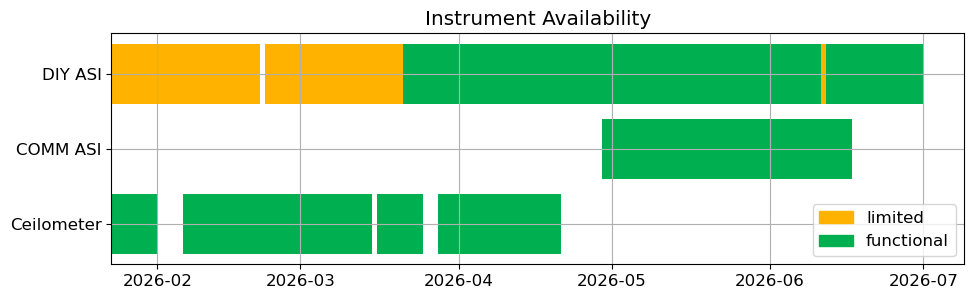

In [11]:
cols = [(1.0,1.0,1.0), (1.0,0.7,0.0), (0,0.69,0.314)]
categories = ["DIY ASI", "COMM ASI", "Ceilometer"]
legend_labels= ["","limited", "functional"]

green_patch = mpl.patches.Patch(color=cols[2], label=legend_labels[2])
yellow_patch = mpl.patches.Patch(color=cols[1], label=legend_labels[1])

plt.figure(figsize=(11,3))
mpl.rcParams.update({'font.size': 12})

for _row in df.iterrows():

    diy_status = int(_row[1]["DIY_ASI"])
    comm_status = int(_row[1]["COMM_ASI"])
    cei_status = int(_row[1]["CEILOMETER"])

    plt.barh(categories[2], dt.timedelta(days=1), left=_row[1]["DATE"], color=cols[cei_status])
    plt.barh(categories[1], dt.timedelta(days=1), left=_row[1]["DATE"], color=cols[comm_status])
    plt.barh(categories[0], dt.timedelta(days=1), left=_row[1]["DATE"], color=cols[diy_status])


plt.gca().xaxis_date()
plt.legend(handles=[yellow_patch, green_patch], loc="lower right")
plt.grid()
plt.title("Instrument Availability")


plt.savefig("instrument_availability.png")